<a href="https://colab.research.google.com/github/nauerromero/Ciencia_de_Datos_II/blob/main/CasoPractico1_Punto2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Sube los archivos studentInfo.csv y studentAssessment.csv


Saving studentAssessment.csv to studentAssessment (1).csv
Saving studentInfo.csv to studentInfo (1).csv


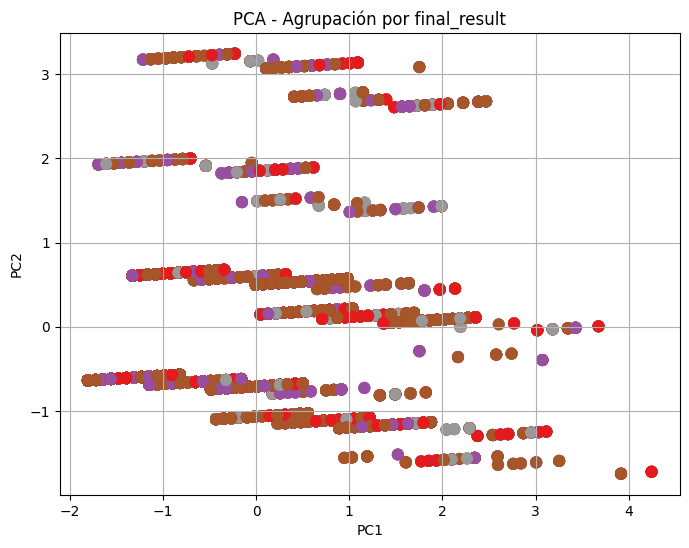

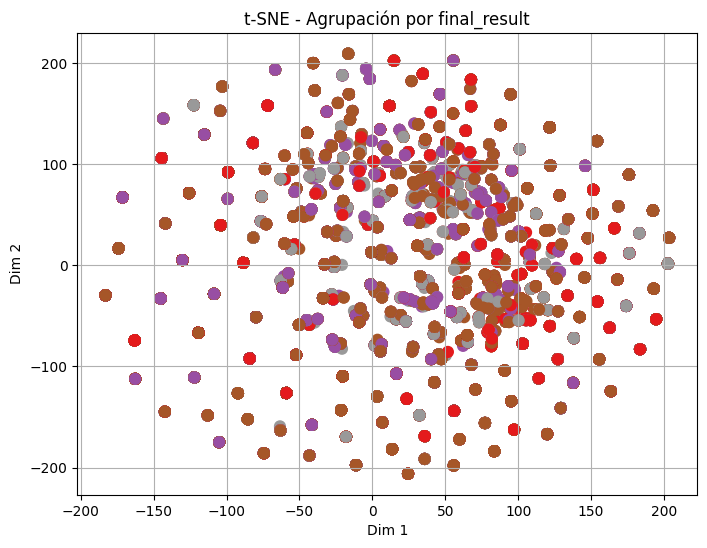

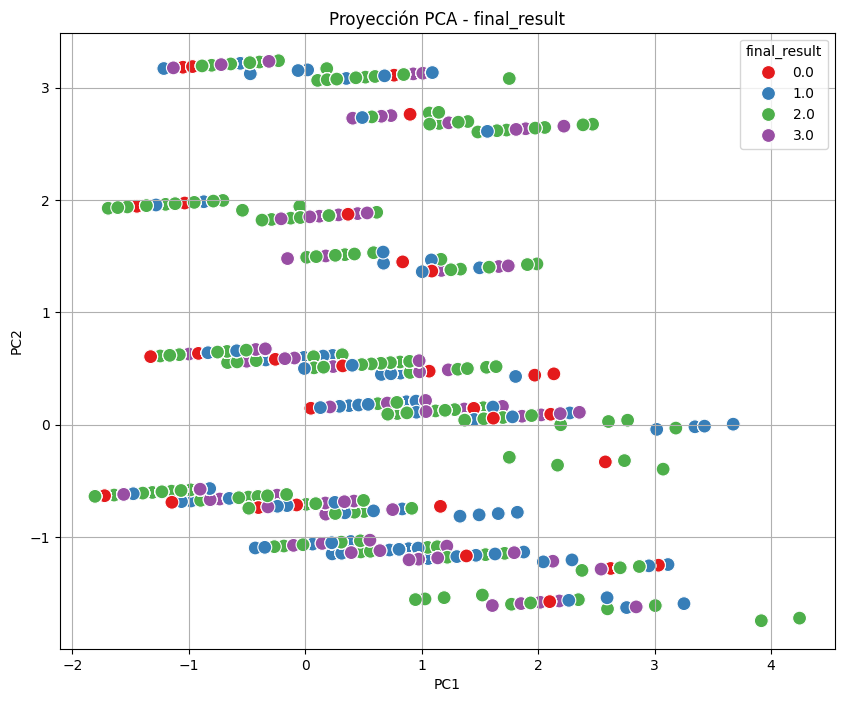

Matriz de cargas PCA:
                        PC1       PC2
gender            -0.237331 -0.617980
age_band           0.658122 -0.219814
region            -0.301709 -0.021267
highest_education  0.646850 -0.051714
disability         0.033256  0.752766
La variable más influyente en PC1 es 'age_band' con un peso de 0.66
La variable más influyente en PC2 es 'disability' con un peso de 0.75

Correlación con 'scale':
scale                1.000000
age_band             0.075023
gender              -0.003272
region              -0.005831
disability          -0.054154
highest_education   -0.056775
Name: scale, dtype: float64

SelectKBest - score para 'scale':
age_band             151.270258
highest_education     86.424075
disability            78.605201
region                 0.908606
gender                 0.286100
dtype: float64

Importancia de variables para 'final_result':
region               0.535176
highest_education    0.238487
age_band             0.092863
disability           0.071724
g

In [ ]:
# INSTALACIÓN Y CONFIGURACIÓN
!pip install seaborn

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.feature_selection import SelectKBest, f_regression, RFE
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

# CARGA INTERACTIVA DE ARCHIVOS
from google.colab import files
print("Sube los archivos studentInfo.csv y studentAssessment.csv")
uploaded = files.upload()

# CARGA DE DATOS
info = pd.read_csv("studentInfo.csv")
assess = pd.read_csv("studentAssessment.csv")

# CALCULAR PROMEDIO DE SCORE POR ESTUDIANTE
score_avg = assess.groupby("id_student")["score"].mean().reset_index()
score_avg.rename(columns={"score": "scale"}, inplace=True)

# UNIR SCORE CON INFO
df = pd.merge(info, score_avg, on="id_student", how="left")

# SELECCIONAR COLUMNAS RELEVANTES
df = df[["gender", "age_band", "region", "highest_education", "disability", "final_result", "scale"]]

# PREPROCESAMIENTO
for col in ["gender", "age_band", "region", "highest_education", "disability", "final_result"]:
    df[col] = LabelEncoder().fit_transform(df[col])

df = df.dropna(subset=["scale"])

X = df.drop(columns=["final_result", "scale"])
y_result = df["final_result"]
y_scale = df["scale"]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(8, 6))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y_result, cmap="Set1", s=60)
plt.title("PCA - Agrupación por final_result")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.grid(True)
plt.show()

# t-SNE
tsne = TSNE(n_components=2, perplexity=30, random_state=42)
X_tsne = tsne.fit_transform(X_scaled)

plt.figure(figsize=(8, 6))
plt.scatter(X_tsne[:, 0], X_tsne[:, 1], c=y_result, cmap="Set1", s=60)
plt.title("t-SNE - Agrupación por final_result")
plt.xlabel("Dim 1")
plt.ylabel("Dim 2")
plt.grid(True)
plt.show()

# PROYECCIÓN COMPARATIVA
proj_df = pd.DataFrame(X_pca, columns=["PC1", "PC2"])
proj_df["final_result"] = y_result

plt.figure(figsize=(10, 8))
sns.scatterplot(data=proj_df, x="PC1", y="PC2", hue="final_result", palette="Set1", s=100)
plt.title("Proyección PCA - final_result")
plt.grid(True)
plt.show()

# MATRIZ DE CARGAS PCA
loadings_df = pd.DataFrame(pca.components_.T, columns=["PC1", "PC2"], index=X.columns)
print("Matriz de cargas PCA:")
print(loadings_df)

for pc in loadings_df.columns:
    var = loadings_df[pc].abs().idxmax()
    peso = loadings_df.loc[var, pc]
    print(f"La variable más influyente en {pc} es '{var}' con un peso de {peso:.2f}")

# CORRELACIÓN CON SCALE
X_corr = df.drop(columns=["final_result"])
corr_matrix = X_corr.corr()
print("\nCorrelación con 'scale':")
print(corr_matrix["scale"].sort_values(ascending=False))

# SELECCIÓN DE VARIABLES
selector_scale = SelectKBest(score_func=f_regression, k='all')
selector_scale.fit(X_scaled, y_scale)
print("\nSelectKBest - score para 'scale':")
print(pd.Series(selector_scale.scores_, index=X.columns).sort_values(ascending=False))

clf = RandomForestClassifier(random_state=42)
clf.fit(X_scaled, y_result)
print("\nImportancia de variables para 'final_result':")
print(pd.Series(clf.feature_importances_, index=X.columns).sort_values(ascending=False))

model = LogisticRegression(max_iter=1000)
rfe = RFE(model, n_features_to_select=5)
rfe.fit(X_scaled, y_result)
print("\nVariables seleccionadas por RFE:")
print(pd.Series(rfe.support_, index=X.columns)[lambda x: x].index.tolist())